## How many buckets / where to split

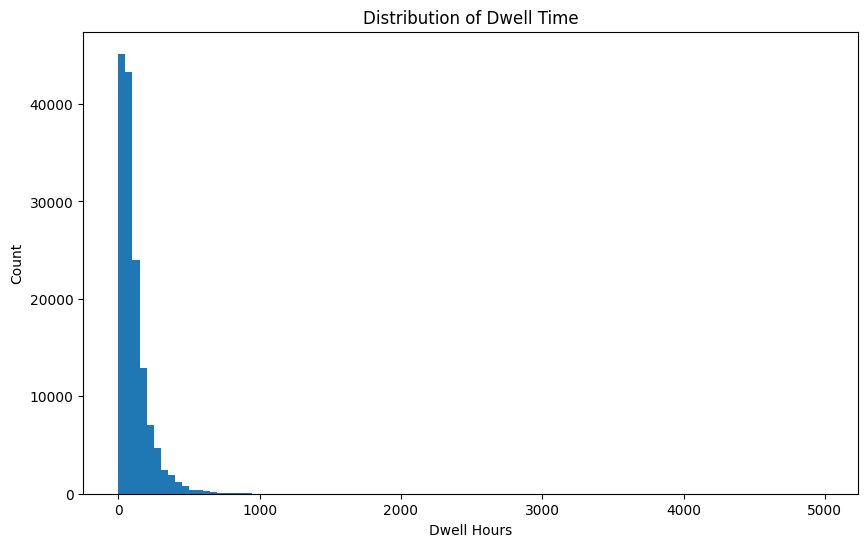

In [2]:
# visualize dataset

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data_final/eurogate_postdeparture_with_ids.csv")

plt.figure(figsize=(10,6))
plt.hist(df["dwell_hours"], bins=100)
plt.xlabel("Dwell Hours")
plt.ylabel("Count")
plt.title("Distribution of Dwell Time")
plt.show()

In [3]:
percentiles = [
    0, 5, 10, 25, 50,
    75, 80, 85, 90,
    95, 97, 99, 100
]

print(
    df["dwell_hours"]
    .quantile([p/100 for p in percentiles])
)

0.00       0.982222
0.05      15.232472
0.10      23.148333
0.25      43.377153
0.50      79.961528
0.75     140.584792
0.80     162.311000
0.85     190.942250
0.90     234.963611
0.95     311.469431
0.97     379.538444
0.99     523.747108
1.00    4986.133333
Name: dwell_hours, dtype: float64


In [5]:
pct_above_720 = (df["dwell_hours"] > 720).mean() * 100
print("should we cut off at 1 month?")
print(f"Percent above 720 hours: {pct_above_720:.2f}%")

should we cut off at 1 month?
Percent above 720 hours: 0.21%


In [6]:
pct_above_720 = (df["dwell_hours"] > 336).mean() * 100
print("should we cut off at 2 weeks?")
print(f"Percent above 720 hours: {pct_above_720:.2f}%")

should we cut off at 2 weeks?
Percent above 720 hours: 4.18%


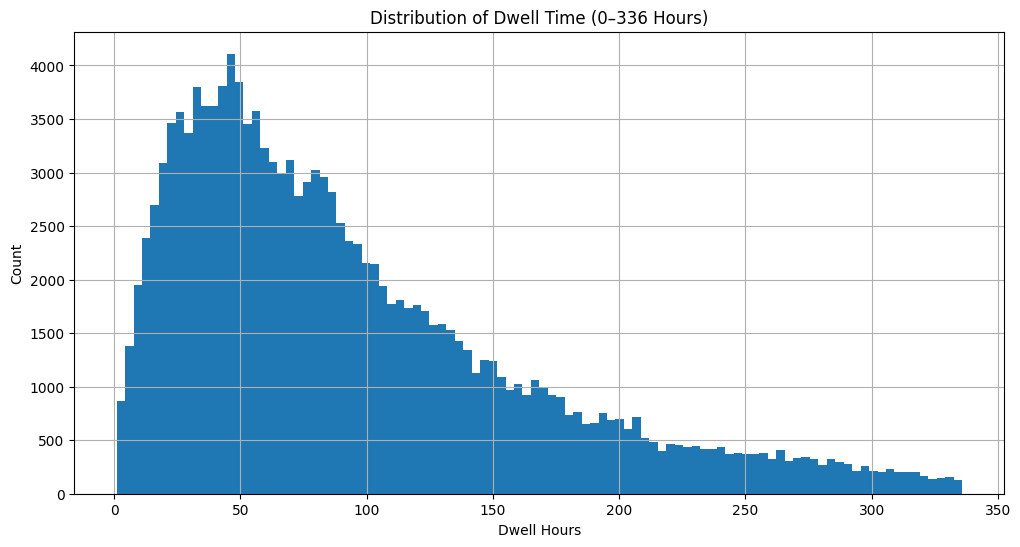

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df.loc[df["dwell_hours"] <= 336, "dwell_hours"].hist(
    bins=100
)

plt.xlabel("Dwell Hours")
plt.ylabel("Count")
plt.title("Distribution of Dwell Time (0–336 Hours)")
plt.show()

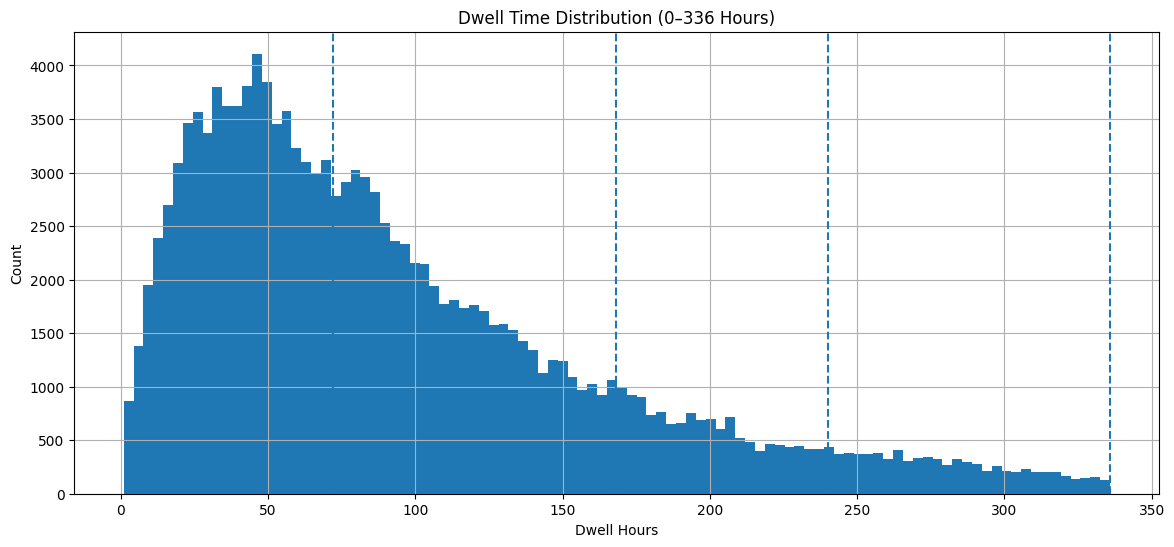

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df.loc[df["dwell_hours"] <= 336, "dwell_hours"].hist(
    bins=100
)

for x in [72, 168, 240, 336]:
    plt.axvline(x, linestyle="--")

plt.xlabel("Dwell Hours")
plt.ylabel("Count")
plt.title("Dwell Time Distribution (0–336 Hours)")
plt.show()

In [10]:
import numpy as np 

bins = [0, 72, 168, 240, 336, np.inf]

bucket_counts = pd.cut(
    df["dwell_hours"],
    bins=bins
).value_counts(normalize=True).sort_index()

print(bucket_counts * 100)

dwell_hours
(0.0, 72.0]       45.231596
(72.0, 168.0]     35.946374
(168.0, 240.0]     9.252137
(240.0, 336.0]     5.390819
(336.0, inf]       4.179074
Name: proportion, dtype: float64


In [ ]:
bins = [0, 48, 96, 168, 336, np.inf]

# bucket 1: 0-2 days
# bucket 2: 2-4 days
# bucket 3: 4-7 days
# bucket 4: 7-14 days

bucket_counts = pd.cut(
    df["dwell_hours"],
    bins=bins
).value_counts(normalize=True).sort_index()

print(bucket_counts * 100)

dwell_hours
(0.0, 48.0]       28.869589
(48.0, 96.0]      29.888337
(96.0, 168.0]     22.420044
(168.0, 336.0]    14.642956
(336.0, inf]       4.179074
Name: proportion, dtype: float64


In [ ]:
bins = [0, 36, 72, 120, 336, np.inf]

# bucket 1: 0-1.5 days
# bucket 2: 1.5-3 days
# bucket 3: 3-5 days
# bucket 4: 5-14 days

bucket_counts = pd.cut(
    df["dwell_hours"],
    bins=bins
).value_counts(normalize=True).sort_index()

print(bucket_counts * 100)

dwell_hours
(0.0, 36.0]       19.489937
(36.0, 72.0]      25.741660
(72.0, 120.0]     23.198925
(120.0, 336.0]    27.390405
(336.0, inf]       4.179074
Name: proportion, dtype: float64


Bucket percentages:
dwell_bucket_candidate
0-48h\n0-2d        28.869589
48-96h\n2-4d       29.888337
96-168h\n4-7d      22.420044
168-336h\n7-14d    14.642956
336h+\n14d+         4.179074
Name: proportion, dtype: float64


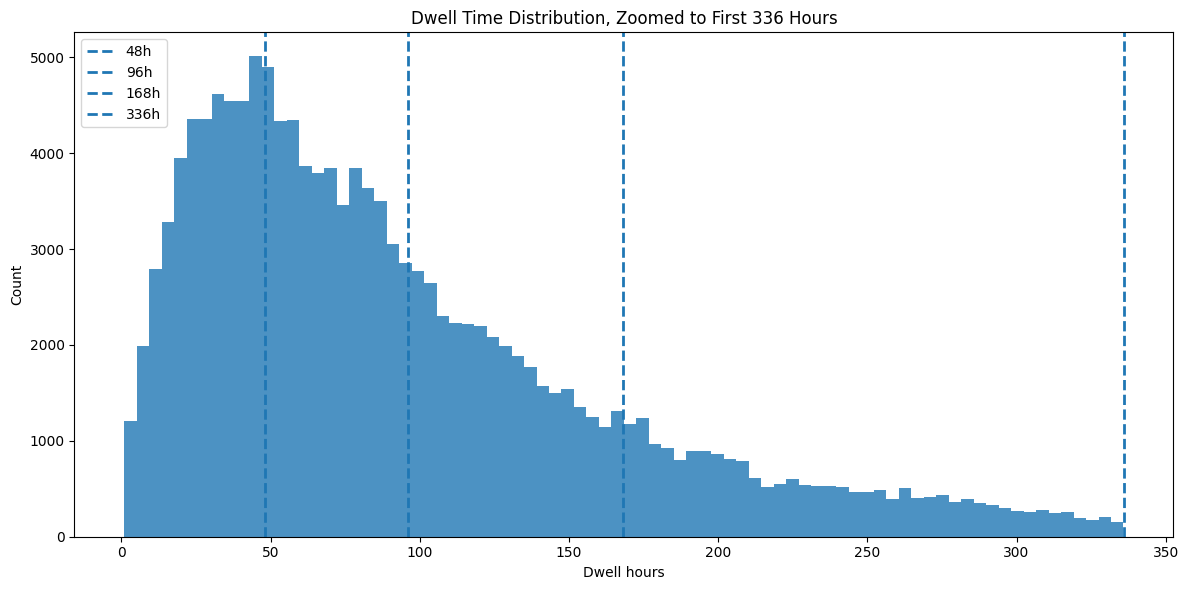

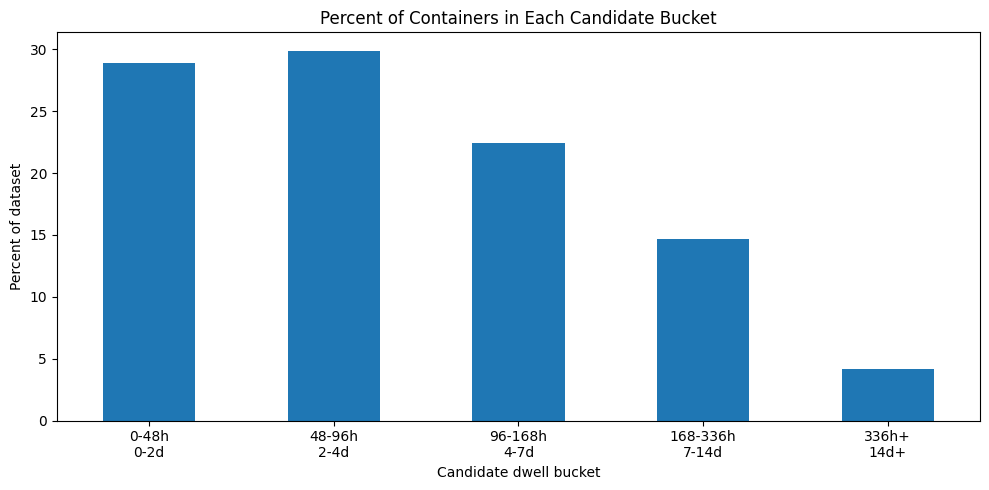

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bins = [0, 48, 96, 168, 336, np.inf]
labels = [
    "0-48h\n0-2d",
    "48-96h\n2-4d",
    "96-168h\n4-7d",
    "168-336h\n7-14d",
    "336h+\n14d+"
]

df["dwell_bucket_candidate"] = pd.cut(
    df["dwell_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bucket_counts = (
    df["dwell_bucket_candidate"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Bucket percentages:")
print(bucket_counts)

dwell_zoom = df.loc[
    df["dwell_hours"].between(0, 336, inclusive="both"),
    "dwell_hours"
]

plt.figure(figsize=(12, 6))

plt.hist(
    dwell_zoom,
    bins=80,
    alpha=0.8
)

for boundary in [48, 96, 168, 336]:
    plt.axvline(
        boundary,
        linestyle="--",
        linewidth=2,
        label=f"{boundary}h"
    )

plt.xlabel("Dwell hours")
plt.ylabel("Count")
plt.title("Dwell Time Distribution, Zoomed to First 336 Hours")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

bucket_counts.plot(kind="bar")

plt.ylabel("Percent of dataset")
plt.xlabel("Candidate dwell bucket")
plt.title("Percent of Containers in Each Candidate Bucket")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Bucket percentages:
dwell_bucket_candidate
0-36h\n0-1.5d      19.489937
36-72h\n1.5-3d     25.741660
72-120h\n3-5d      23.198925
120-336h\n5-14d    27.390405
336h+\n14d+         4.179074
Name: proportion, dtype: float64


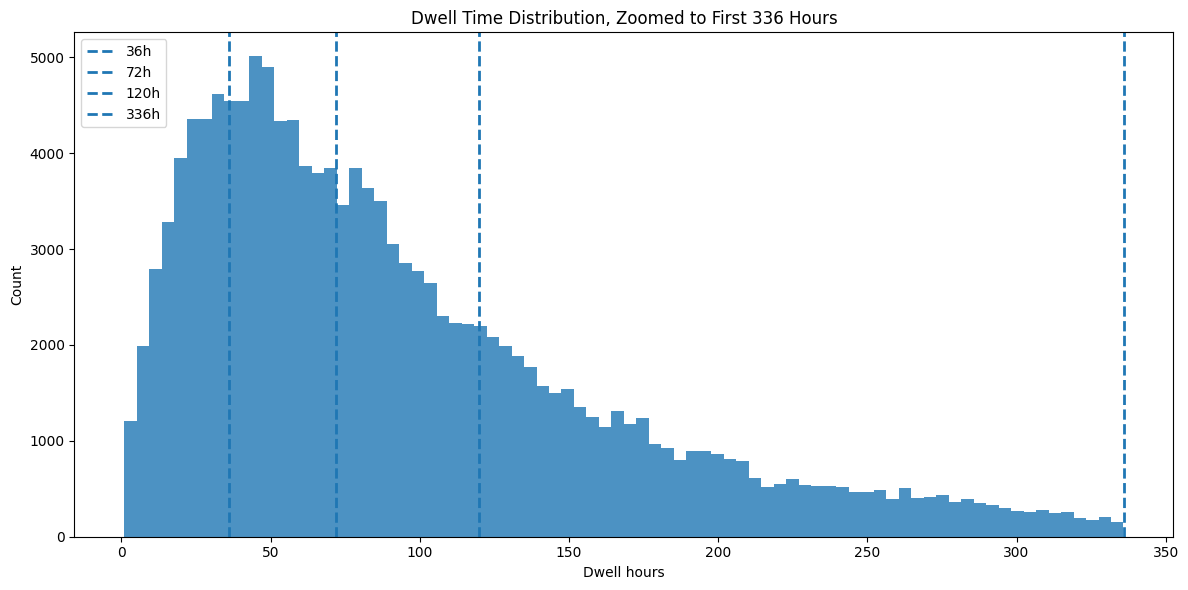

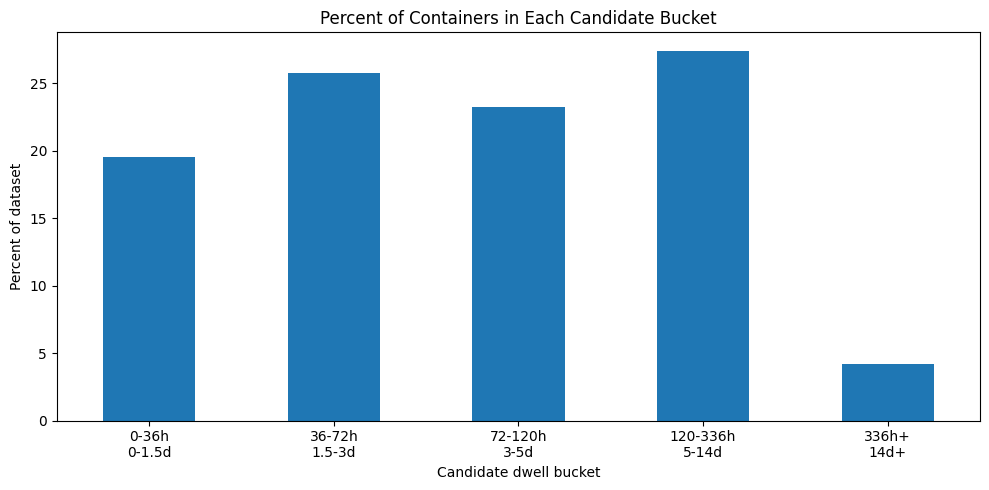

In [24]:
# bucket 1: 0-1.5 days
# bucket 2: 1.5-3 days
# bucket 3: 3-5 days
# bucket 4: 5-14 days

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bins = [0, 36, 72, 120, 336, np.inf]
labels = [
    "0-36h\n0-1.5d",
    "36-72h\n1.5-3d",
    "72-120h\n3-5d",
    "120-336h\n5-14d",
    "336h+\n14d+"
]

df["dwell_bucket_candidate"] = pd.cut(
    df["dwell_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bucket_counts = (
    df["dwell_bucket_candidate"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Bucket percentages:")
print(bucket_counts)

dwell_zoom = df.loc[
    df["dwell_hours"].between(0, 336, inclusive="both"),
    "dwell_hours"
]

plt.figure(figsize=(12, 6))

plt.hist(
    dwell_zoom,
    bins=80,
    alpha=0.8
)

for boundary in [36, 72, 120, 336]:
    plt.axvline(
        boundary,
        linestyle="--",
        linewidth=2,
        label=f"{boundary}h"
    )

plt.xlabel("Dwell hours")
plt.ylabel("Count")
plt.title("Dwell Time Distribution, Zoomed to First 336 Hours")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

bucket_counts.plot(kind="bar")

plt.ylabel("Percent of dataset")
plt.xlabel("Candidate dwell bucket")
plt.title("Percent of Containers in Each Candidate Bucket")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Test multiple models w/ 4 buckets, drop 14+ days

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier
)

df_trimmed = df[df["dwell_hours"] <= 336].copy()

print("Rows remaining:", len(df_trimmed))

bins = [0, 36, 72, 120, 336]

df_trimmed["dwell_bucket"] = pd.cut(
    df_trimmed["dwell_hours"],
    bins=bins,
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

print("\nBucket distribution:")
print(
    df_trimmed["dwell_bucket"]
    .value_counts(normalize=True)
    .sort_index()
)

drop_cols = [
    "dwell_hours",
    "dwell_bucket",
    "dwell_bucket_candidate",
    "dwell_bucket_3",
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",
    "containerId"
]

X = df_trimmed.drop(
    columns=[c for c in drop_cols if c in df_trimmed.columns]
)

non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Still non-numeric:", non_numeric_cols)

y = df_trimmed["dwell_bucket"]

object_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nDropping object columns:")
print(object_cols)

X = X.drop(columns=object_cols)

X = X.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

models = {
    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            max_iter=300,
            random_state=42
        ),

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            n_jobs=-1
        ),

    "Ridge Classifier":
        RidgeClassifier(
            class_weight="balanced"
        )
}

results = []
for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    bal_acc = balanced_accuracy_score(y_test, pred)

    results.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, pred))

    print("\nClassification Report")
    print(classification_report(y_test, pred))

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "balanced_accuracy",
        ascending=False
    )
)

print("\n\nFinal Comparison")
print(results_df)

best_model = ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

print("\nTop 30 Features")
print(importance_df.head(30))

importance_df.to_csv(
    "../feature_importance/four_bucket_feature_importance.csv",
    index=False
)

results_df.to_csv(
    "../feature_importance/four_bucket_model_comparison.csv",
    index=False
)

Rows remaining: 139017

Bucket distribution:
dwell_bucket
0    0.203400
1    0.268643
2    0.242107
3    0.285850
Name: proportion, dtype: float64
Still non-numeric: []

Dropping object columns:
[]

Extra Trees
Accuracy: 0.6530
Balanced Accuracy: 0.6535

Confusion Matrix
[[3975  803  435  442]
 [ 821 4898 1030  720]
 [ 543 1132 3850 1207]
 [ 486  866 1163 5433]]

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      5655
           1       0.64      0.66      0.65      7469
           2       0.59      0.57      0.58      6732
           3       0.70      0.68      0.69      7948

    accuracy                           0.65     27804
   macro avg       0.65      0.65      0.65     27804
weighted avg       0.65      0.65      0.65     27804


Random Forest
Accuracy: 0.6570
Balanced Accuracy: 0.6566

Confusion Matrix
[[3906  875  439  435]
 [ 831 4966  964  708]
 [ 516 1143 3901 1172]
 [ 452  857 1144 5495]]

Classif

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.3588
Balanced Accuracy: 0.3565

Confusion Matrix
[[2357 1505  623 1170]
 [2187 2707  966 1609]
 [1772 1506 1276 2178]
 [1733 1360 1220 3635]]

Classification Report
              precision    recall  f1-score   support

           0       0.29      0.42      0.34      5655
           1       0.38      0.36      0.37      7469
           2       0.31      0.19      0.24      6732
           3       0.42      0.46      0.44      7948

    accuracy                           0.36     27804
   macro avg       0.35      0.36      0.35     27804
weighted avg       0.36      0.36      0.35     27804


Ridge Classifier


/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.0836e-14): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Accuracy: 0.4349
Balanced Accuracy: 0.4339

Confusion Matrix
[[2853 1208  768  826]
 [2238 2952 1082 1197]
 [1366 1527 1973 1866]
 [1240 1087 1308 4313]]

Classification Report
              precision    recall  f1-score   support

           0       0.37      0.50      0.43      5655
           1       0.44      0.40      0.41      7469
           2       0.38      0.29      0.33      6732
           3       0.53      0.54      0.53      7948

    accuracy                           0.43     27804
   macro avg       0.43      0.43      0.43     27804
weighted avg       0.44      0.43      0.43     27804



Final Comparison
                    model  accuracy  balanced_accuracy
1           Random Forest  0.657028           0.656609
0             Extra Trees  0.653000           0.653540
2  Hist Gradient Boosting  0.614264           0.608580
4        Ridge Classifier  0.434865           0.433868
3     Logistic Regression  0.358761           0.356530

Top 30 Features
                      

In [27]:
print(list(X.columns))

['iedCode', 'reefer', 'teu', 'gross', 'arrivalLocationX', 'arrivalLocationY', 'arrivalLocationZ', 'released', 'numberOfArrivalContainersOnVessel', 'numberOfRemainOnBoardContainersOnVessel', 'numberOfDepartureContainersOnVessel', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'weather_code', 'cloud_cover', 'wind_speed_10m', 'wind_gusts_10m', 'is_raining', 'bad_weather_score', 'iso_22GB', 'iso_22K2', 'iso_22P3', 'iso_22R1', 'iso_22T1', 'iso_22T6', 'iso_22U1', 'iso_25G1', 'iso_42G1', 'iso_42P3', 'iso_42U1', 'iso_45G0', 'iso_45G1', 'iso_45P3', 'iso_45R1', 'iso_45R5', 'iso_45U1', 'iso_4EG1', 'iso_L5G1', 'iso_OTHER', 'arrival_hour', 'arrival_dayofweek', 'arrival_month', 'arrival_is_weekend', 'arrival_hour_sin', 'arrival_hour_cos', 'arrival_month_sin', 'arrival_month_cos', 'eta_error_hours', 'arrivalPolCode_freq', 'arrivalVesselName_freq', 'service_Arctic Container Lines AS', 'service_BOERDE', 'service_Baltic Sea, etc (UNIFEEDER) FLZ', 'service_CMA CGM EPIC', 'service_CMA 

## Refine model, focus on RF/ET, punish underestimates

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

df_trimmed = df[df["dwell_hours"] <= 336].copy()

bins = [0, 36, 72, 120, 336]
labels = [0, 1, 2, 3]

df_trimmed["dwell_bucket"] = pd.cut(
    df_trimmed["dwell_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

print("Rows remaining:", len(df_trimmed))
print("\nBucket distribution:")
print(df_trimmed["dwell_bucket"].value_counts(normalize=True).sort_index())

drop_cols = [
    "dwell_hours",
    "dwell_bucket",
    "dwell_bucket_candidate",
    "dwell_bucket_3",

    "containerId",

    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",

    # Drop location-related columns
    "arrivalLocationX",
    "arrivalLocationY",
    "arrivalLocationZ",
]

X = df_trimmed.drop(columns=[c for c in drop_cols if c in df_trimmed.columns])
y = df_trimmed["dwell_bucket"]

X = X.replace([np.inf, -np.inf], np.nan)

non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nDropping non-numeric columns:")
print(non_numeric_cols)

X = X.drop(columns=non_numeric_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))
X = X.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Underestimation-aware prediction
def predict_with_upward_bias(probs, margin=0.10):
    """
    Normal prediction = class with max probability.

    Upward-biased rule:
    If a higher bucket is close enough to the max probability,
    choose the higher bucket.

    Smaller margin = more upward bias.
    Larger margin = closer to normal argmax.
    """
    preds = []

    for row in probs:
        best_class = np.argmax(row)
        best_prob = row[best_class]

        chosen = best_class

        for higher_class in range(best_class + 1, len(row)):
            if row[higher_class] >= best_prob - margin:
                chosen = higher_class

        preds.append(chosen)

    return np.array(preds)


def evaluate_predictions(name, y_true, pred):
    acc = accuracy_score(y_true, pred)
    bal_acc = balanced_accuracy_score(y_true, pred)

    under = (pred < y_true).mean()
    over = (pred > y_true).mean()
    exact = (pred == y_true).mean()

    avg_error = np.mean(pred - y_true)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Exact bucket: {exact:.4f}")
    print(f"Underestimated bucket rate: {under:.4f}")
    print(f"Overestimated bucket rate: {over:.4f}")
    print(f"Average bucket error pred-actual: {avg_error:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, pred))

    print("\nClassification Report")
    print(classification_report(y_true, pred, zero_division=0))

    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "exact_rate": exact,
        "under_rate": under,
        "over_rate": over,
        "avg_bucket_error": avg_error
    }


# Models
models = {
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=40,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features=0.75,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=40,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

all_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)

    # Normal argmax prediction
    pred_normal = np.argmax(probs, axis=1)

    normal_metrics = evaluate_predictions(
        f"{model_name} - Normal Argmax",
        y_test,
        pred_normal
    )

    all_results.append({
        "model": model_name,
        "strategy": "normal_argmax",
        "margin": np.nan,
        **normal_metrics
    })

    # Upward-biased versions
    for margin in [0.03, 0.05, 0.075, 0.10, 0.15]:
        pred_up = predict_with_upward_bias(probs, margin=margin)

        metrics = evaluate_predictions(
            f"{model_name} - Upward Bias margin={margin}",
            y_test,
            pred_up
        )

        all_results.append({
            "model": model_name,
            "strategy": "upward_bias",
            "margin": margin,
            **metrics
        })

# Summary
results_df = pd.DataFrame(all_results)

print("\n\nFinal comparison:")
print(
    results_df.sort_values(
        ["under_rate", "accuracy"],
        ascending=[True, False]
    )
)

results_df.to_csv(
    "../feature_importance/four_bucket_underestimate_aware_results.csv",
    index=False
)

# Feature importance from Extra Trees
et = models["Extra Trees"]

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": et.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 30 Extra Trees Features:")
print(importance_df.head(30))

importance_df.to_csv(
    "../feature_importance/four_bucket_no_location_feature_importance.csv",
    index=False
)

Rows remaining: 139017

Bucket distribution:
dwell_bucket
0    0.203400
1    0.268643
2    0.242107
3    0.285850
Name: proportion, dtype: float64

Dropping non-numeric columns:
[]

Extra Trees - Normal Argmax
Accuracy: 0.6305
Balanced Accuracy: 0.6302
Exact bucket: 0.6305
Underestimated bucket rate: 0.1982
Overestimated bucket rate: 0.1712
Average bucket error pred-actual: -0.0446

Confusion Matrix
[[3712  959  566  418]
 [1177 4473 1165  654]
 [ 664 1122 3947  999]
 [ 555  771 1223 5399]]

Classification Report
              precision    recall  f1-score   support

           0       0.61      0.66      0.63      5655
           1       0.61      0.60      0.60      7469
           2       0.57      0.59      0.58      6732
           3       0.72      0.68      0.70      7948

    accuracy                           0.63     27804
   macro avg       0.63      0.63      0.63     27804
weighted avg       0.63      0.63      0.63     27804


Extra Trees - Upward Bias margin=0.03
Accurac

## focus on RF w/ 0.05 bias to mitigate underestimation

In [30]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

OUT_DIR = "../feature_importance"
TARGET = "dwell_bucket"

# existing df
df_trimmed = df[df["dwell_hours"] <= 336].copy()

# buckets:
# 0 = 0-36h
# 1 = 36-72h
# 2 = 72-120h
# 3 = 120-336h
bins = [0, 36, 72, 120, 336]

df_trimmed[TARGET] = pd.cut(
    df_trimmed["dwell_hours"],
    bins=bins,
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

print("Rows remaining:", len(df_trimmed))
print("\nBucket distribution:")
print(df_trimmed[TARGET].value_counts(normalize=True).sort_index())

drop_cols = [
    "dwell_hours",
    "dwell_bucket",
    "dwell_bucket_candidate",
    "dwell_bucket_3",
    "containerId",
    "snapshot_time",
    "snapshot_date",
    "snapshot_year",
    "snapshot_hour",
    "snapshot_minute",
    "snapshot_second",
    "arrival_year",

    # dropped for no-location model
    "arrivalLocationX",
    "arrivalLocationY",
    "arrivalLocationZ",
]

X = df_trimmed.drop(columns=[c for c in drop_cols if c in df_trimmed.columns])
y = df_trimmed[TARGET]

X = X.replace([np.inf, -np.inf], np.nan)

non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nDropping non-numeric columns:")
print(non_numeric_cols)
X = X.drop(columns=non_numeric_cols)

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))
X = X.astype(np.float32)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# prediciton strategies
def predict_upward_bias(probs, margin):
    preds = []

    for row in probs:
        best_class = np.argmax(row)
        best_prob = row[best_class]
        chosen = best_class

        for higher_class in range(best_class + 1, len(row)):
            if row[higher_class] >= best_prob - margin:
                chosen = higher_class

        preds.append(chosen)

    return np.array(preds)


def predict_expected_bucket(probs, offset=0.15):
    bucket_nums = np.arange(probs.shape[1])
    expected = probs @ bucket_nums

    pred = np.ceil(expected - offset).astype(int)
    pred = np.clip(pred, 0, probs.shape[1] - 1)

    return pred


def evaluate_preds(y_true, pred):
    acc = accuracy_score(y_true, pred)
    bal_acc = balanced_accuracy_score(y_true, pred)

    under = (pred < y_true).mean()
    over = (pred > y_true).mean()
    exact = (pred == y_true).mean()

    severe_under = (pred <= y_true - 2).mean()
    severe_over = (pred >= y_true + 2).mean()

    avg_bucket_error = np.mean(pred - y_true)

    # change the cost!!! for preventing underestimate
    cost = (
        3.0 * under
        + 1.0 * over
        + 5.0 * severe_under
        + 1.0 * (1.0 - acc)
    )

    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "exact_rate": exact,
        "under_rate": under,
        "over_rate": over,
        "severe_under_rate": severe_under,
        "severe_over_rate": severe_over,
        "avg_bucket_error": avg_bucket_error,
        "custom_cost": cost
    }

# tuning RF
param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [25, 40, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5],
    "class_weight": [
        "balanced",
        {0: 1.0, 1: 1.1, 2: 1.3, 3: 1.6},
        {0: 1.0, 1: 1.2, 2: 1.5, 3: 2.0},
    ]
}

margins = np.arange(0.00, 0.151, 0.01)
expected_offsets = [0.00, 0.10, 0.15, 0.20, 0.25]

all_results = []
best_record = None
best_model = None
best_pred = None
best_probs = None

for i, params in enumerate(ParameterGrid(param_grid), start=1):
    print(f"\nTraining RF candidate {i}")

    model = RandomForestClassifier(
        **params,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)

    # attempt 1-  normal argmax
    pred = np.argmax(probs, axis=1)
    metrics = evaluate_preds(y_test, pred)

    record = {
        "strategy": "argmax",
        "margin": np.nan,
        "expected_offset": np.nan,
        **params,
        **metrics
    }

    all_results.append(record)

    if best_record is None or record["custom_cost"] < best_record["custom_cost"]:
        best_record = record
        best_model = model
        best_pred = pred
        best_probs = probs

    # attempt 2-  upward bias margins
    for margin in margins:
        pred = predict_upward_bias(probs, margin)
        metrics = evaluate_preds(y_test, pred)

        record = {
            "strategy": "upward_bias",
            "margin": margin,
            "expected_offset": np.nan,
            **params,
            **metrics
        }

        all_results.append(record)

        if record["custom_cost"] < best_record["custom_cost"]:
            best_record = record
            best_model = model
            best_pred = pred
            best_probs = probs

    # attempt 3-  expected bucket
    for offset in expected_offsets:
        pred = predict_expected_bucket(probs, offset=offset)
        metrics = evaluate_preds(y_test, pred)

        record = {
            "strategy": "expected_bucket",
            "margin": np.nan,
            "expected_offset": offset,
            **params,
            **metrics
        }

        all_results.append(record)

        if record["custom_cost"] < best_record["custom_cost"]:
            best_record = record
            best_model = model
            best_pred = pred
            best_probs = probs

# results
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    ["custom_cost", "under_rate", "accuracy"],
    ascending=[True, True, False]
)

print("\nBest record:")
print(best_record)

print("\nTop 20 configurations:")
print(results_df.head(20))

results_df.to_csv(
    f"{OUT_DIR}/rf_bucket_underestimate_tuning_results.csv",
    index=False
)

# which model is best
print("\n" + "=" * 70)
print("BEST MODEL REPORT")
print("=" * 70)

print(f"Strategy: {best_record['strategy']}")
print(f"Margin: {best_record['margin']}")
print(f"Expected offset: {best_record['expected_offset']}")
print(f"Custom cost: {best_record['custom_cost']:.4f}")
print(f"Accuracy: {best_record['accuracy']:.4f}")
print(f"Balanced accuracy: {best_record['balanced_accuracy']:.4f}")
print(f"Under rate: {best_record['under_rate']:.4f}")
print(f"Over rate: {best_record['over_rate']:.4f}")
print(f"Severe under rate: {best_record['severe_under_rate']:.4f}")
print(f"Average bucket error: {best_record['avg_bucket_error']:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification report:")
print(classification_report(y_test, best_pred, zero_division=0))

# SAVE PREDICTIONS
predictions = pd.DataFrame({
    "actual_bucket": y_test.values,
    "predicted_bucket": best_pred,
    "prob_bucket_0": best_probs[:, 0],
    "prob_bucket_1": best_probs[:, 1],
    "prob_bucket_2": best_probs[:, 2],
    "prob_bucket_3": best_probs[:, 3],
    "bucket_error": best_pred - y_test.values
})

predictions.to_csv(
    f"{OUT_DIR}/rf_bucket_best_predictions.csv",
    index=False
)

# FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv(
    f"{OUT_DIR}/rf_bucket_best_feature_importance.csv",
    index=False
)

print("\nTop 30 features:")
print(importance_df.head(30))

# SAVE MODEL
joblib.dump(
    best_model,
    f"{OUT_DIR}/rf_bucket_best_model.joblib"
)

print("\nSaved:")
print(f"{OUT_DIR}/rf_bucket_underestimate_tuning_results.csv")
print(f"{OUT_DIR}/rf_bucket_best_predictions.csv")
print(f"{OUT_DIR}/rf_bucket_best_feature_importance.csv")
print(f"{OUT_DIR}/rf_bucket_best_model.joblib")

Rows remaining: 139017

Bucket distribution:
dwell_bucket
0    0.203400
1    0.268643
2    0.242107
3    0.285850
Name: proportion, dtype: float64

Dropping non-numeric columns:
[]

Training RF candidate 1

Training RF candidate 2

Training RF candidate 3

Training RF candidate 4

Training RF candidate 5

Training RF candidate 6

Training RF candidate 7

Training RF candidate 8

Training RF candidate 9

Training RF candidate 10

Training RF candidate 11

Training RF candidate 12

Training RF candidate 13

Training RF candidate 14

Training RF candidate 15

Training RF candidate 16

Training RF candidate 17

Training RF candidate 18

Training RF candidate 19

Training RF candidate 20

Training RF candidate 21

Training RF candidate 22

Training RF candidate 23

Training RF candidate 24

Training RF candidate 25

Training RF candidate 26

Training RF candidate 27

Training RF candidate 28

Training RF candidate 29

Training RF candidate 30

Training RF candidate 31

Training RF candidate

In [31]:
# focus on maximizing recall 